In [3]:
! pip install langgraph


   ---------------------------------------- 0.0/548.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/548.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/548.1 kB ? eta -:--:--
   ------------------- -------------------- 262.1/548.1 kB ? eta -:--:--
   ------------------- -------------------- 262.1/548.1 kB ? eta -:--:--
   ------------------- -------------------- 262.1/548.1 kB ? eta -:--:--
   ---------------------------------------- 548.1/548.1 kB 477.0 kB/s  0:00:01

   -------- -------------------------------  3/15 [ormsgpack]
   ---------------- -----------------------  6/15 [jsonpointer]
   ------------------ ---------------------  7/15 [requests-toolbelt]
   ------------------ ---------------------  7/15 [requests-toolbelt]
   ------------------ ---------------------  7/15 [requests-toolbelt]
   ------------------ ---------------------  7/15 [requests-toolbelt]
   --------------------- ------------------  8/15 [jsonpatch]
   -----------------


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Hello World Agent



In [1]:
from typing import TypedDict, Dict
from langgraph.graph import StateGraph, START, END

In [2]:
from typing import TypedDict

#Lets create AgentState a shared data structure that keeps track of the information as application runs

class AgentState(TypedDict):
    message :  str


def greeting_node(state: AgentState) -> AgentState:                       # return type
    """Simple node that add a greeting message to the state"""

    state['message'] = "Hey" + state["message"] + ", how is your day going?"

    return state

In [3]:
#to add a graph 

graph = StateGraph(AgentState)

graph.add_node("greeter", greeting_node)

graph.add_edge(START, "greeter")
graph.add_edge("greeter", END)

app = graph.compile()



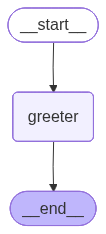

In [4]:
from IPython.display import Image, display

# Display the compiled graph ('app') as an image
display(Image(app.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)))


In [5]:
result = app.invoke({"message": "Bob"})

In [6]:
result["message"]

'HeyBob, how is your day going?'

## Task 

- create a personalized Compliment Agent using LangGraph

- input : {"name": "Bob"}
- ouput: "Bob, you're doing an amazing job learning langGraph"

In [7]:
from langgraph.graph import StateGraph, START, END


In [8]:
class agent_State(TypedDict):
    name : str
    message : str


def helper_node(agent_State: agent_State) -> agent_State:

    agent_State["message"] = agent_State["name"] + ", you're doing an amazing job learning langGraph" 

    return agent_State

In [9]:
graph = StateGraph(agent_State)

graph.add_node("kidmat",helper_node)
graph.add_edge(START, "kidmat")
graph.add_edge("kidmat", END)


In [10]:
app = graph.compile()

In [11]:
result = app.invoke({"name": "Bob"})

In [12]:
result["message"]

"Bob, you're doing an amazing job learning langGraph"